# Day 12 — Data Visualization with Matplotlib
Code it yourself (about 2 hours) — use the Titanic dataset

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 1. Histogram of passenger ages
Try different bin counts and see how the story changes.

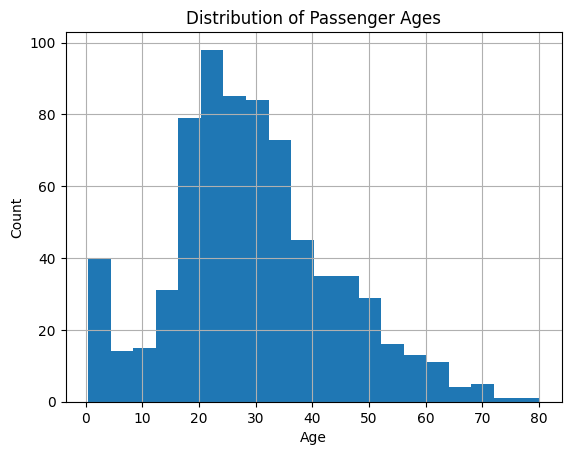

In [2]:
df["age"].hist(bins=20)
plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

## 2. Bar chart of survival rate by class
Using yesterday's groupby result as the input.

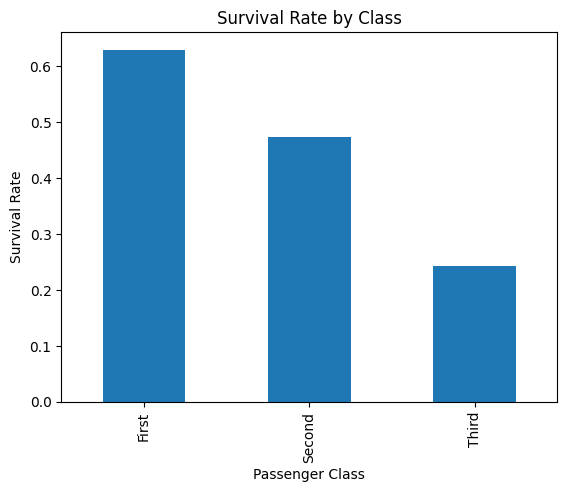

In [3]:
df.groupby("class", observed=False)["survived"].mean().plot(kind="bar")
plt.title("Survival Rate by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

## 3. Bar chart of survival rate by sex

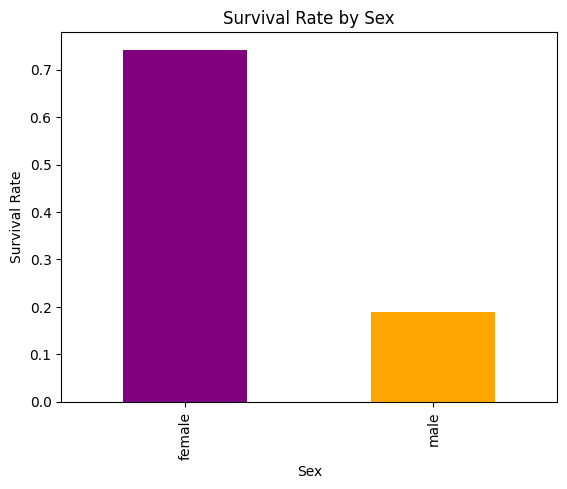

In [4]:
df.groupby("sex")["survived"].mean().plot(kind="bar", color=["purple", "orange"])
plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.show()

## 4. Scatter plot of age vs fare
Do you see any relationship?

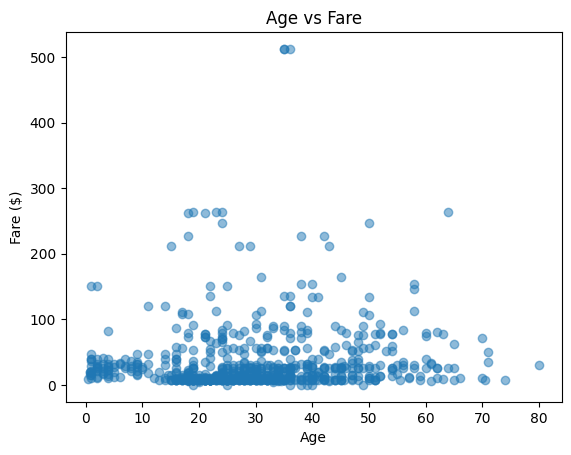

In [5]:
plt.scatter(df["age"], df["fare"], alpha=0.5)
plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare ($)")
plt.show()

## 5. 2×2 Grid of subplots
All four charts together with titles, axis labels, and legends.

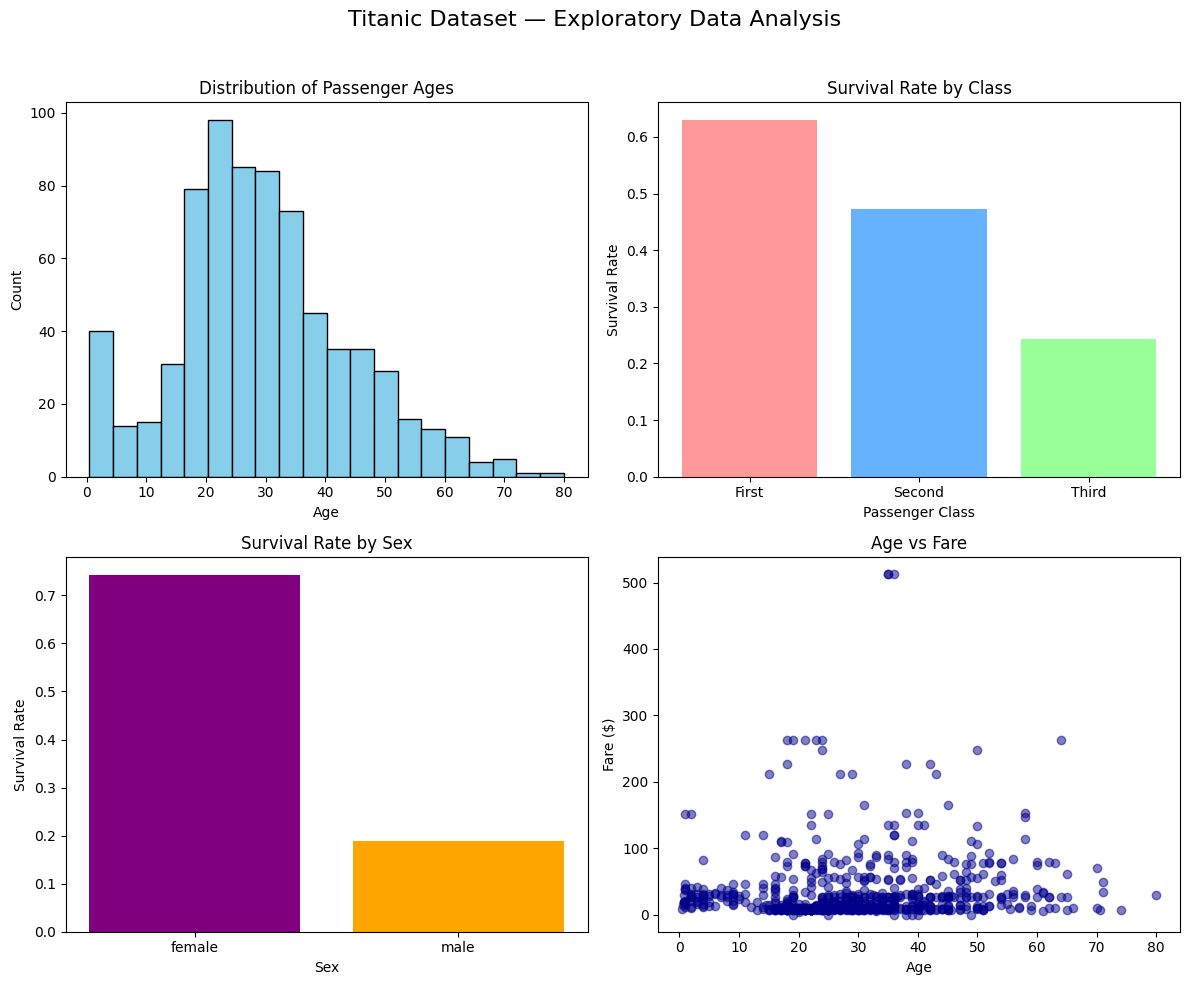

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Titanic Dataset — Exploratory Data Analysis", fontsize=16)

# Histogram
axes[0, 0].hist(df["age"].dropna(), bins=20, color="skyblue", edgecolor="black")
axes[0, 0].set_title("Distribution of Passenger Ages")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Count")

# Survival by class
survival_by_class = df.groupby("class", observed=False)["survived"].mean()
axes[0, 1].bar(survival_by_class.index, survival_by_class.values, color=["#FF9999", "#66B2FF", "#99FF99"])
axes[0, 1].set_title("Survival Rate by Class")
axes[0, 1].set_xlabel("Passenger Class")
axes[0, 1].set_ylabel("Survival Rate")

# Survival by sex
survival_by_sex = df.groupby("sex")["survived"].mean()
axes[1, 0].bar(survival_by_sex.index, survival_by_sex.values, color=["purple", "orange"])
axes[1, 0].set_title("Survival Rate by Sex")
axes[1, 0].set_xlabel("Sex")
axes[1, 0].set_ylabel("Survival Rate")

# Scatter: age vs fare
axes[1, 1].scatter(df["age"], df["fare"], alpha=0.5, color="darkblue")
axes[1, 1].set_title("Age vs Fare")
axes[1, 1].set_xlabel("Age")
axes[1, 1].set_ylabel("Fare ($)")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 6. Mini-challenge
Recreate your most interesting groupby insight from Day 11 as a clean, fully-labeled bar chart that a non-technical person could understand at a glance.

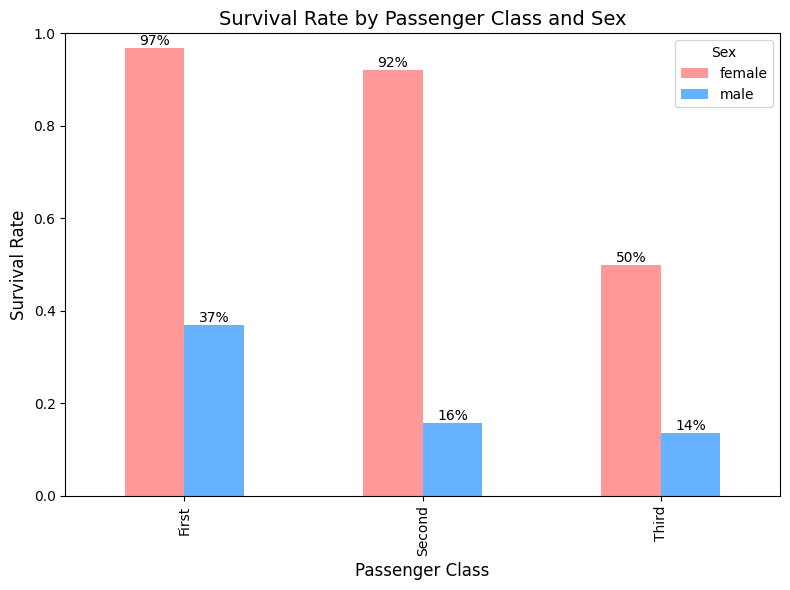

In [7]:
insight = df.groupby(["class", "sex"], observed=False)["survived"].mean().unstack()

ax = insight.plot(kind="bar", figsize=(8, 6), color=["#ff9999", "#66b2ff"])
ax.set_title("Survival Rate by Passenger Class and Sex", fontsize=14)
ax.set_xlabel("Passenger Class", fontsize=12)
ax.set_ylabel("Survival Rate", fontsize=12)
ax.legend(title="Sex")
ax.set_ylim(0, 1)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.0%}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha="center", va="center", xytext=(0, 5), textcoords="offset points")

plt.tight_layout()
plt.show()